# AIFS vs ERA5 RMSE Analysis Notebook

This notebook analyzes Root Mean Square Error (RMSE) between AIFS forecasts and ERA5 reanalysis over Central Europe. It includes:
- Spatial RMSE maps with geographic backgrounds (Köppen climate zones, orography)
- Temporal aggregations (by lead step, day, and hour)
- Comparative analysis across variables (2m temperature, 500 hPa temperature)
- Land-sea and diurnal cycle analysis

**Output**: High-resolution maps and skill plots saved to `results/` directory.

## Notebook Overview

This notebook orchestrates a complete AIFS vs ERA5 analysis pipeline in five stages:

1. **Setup & Configuration** (cells 2–3): Initialize paths, load dependencies, and configure plotting parameters
2. **Data Access & Indexing** (cells 4–6): Download AIFS and ERA5 data (if missing), then scan and index files
3. **Pairing & Computation** (cells 7–8): Match AIFS forecasts with corresponding ERA5 reanalysis times, compute RMSE per pair
4. **Aggregation** (cell 9): Group RMSE by lead time, date, and hour; save NetCDF + CSV outputs
5. **Analysis & Visualization** (cells 10–15): Generate publication-quality spatial maps and time-series plots

**Key design principles:**
- **Idempotent**: Running the notebook multiple times produces the same results (existing files are reused unless overwritten)
- **Resilient**: Failed downloads or missing data are logged; partial runs can resume
- **Configurable**: Most parameters (plot colors, coarsening factors, spatial regions) can be tuned via `PLOT_CFG` dict and config files
- **Documented**: Each section explains what's happening and why; see config files for detailed parameter descriptions

**ERA5** (ECMWF Reanalysis v5) is global climate reanalysis from the European Centre for Medium-Range Weather Forecasts. It blends observations (satellites, weather stations, aircraft) with model data via advanced data assimilation.

| Property | Details |
|---|---|
| **Spatial resolution** | ~31 km on regular latitude-longitude grid |
| **Temporal resolution** | Hourly; this pipeline uses 6-hourly (4 times per day) |
| **Variables** | 200+ including temperature, humidity, wind, pressure |
| **Pressure levels** | 37 levels from surface to stratosphere |
| **Coverage** | Global (0–360° longitude, −90–90° latitude) |
| **Data latency** | ~3 months behind real-time | The near-real time download is available but not quallity-controled. The last 5 days are not available.



## Artificial Intelligence / Integrated Forecasting System (AIFS)

The **Artificial Intelligence / Integrated Forecasting System (AIFS)** is a global forecasting system developed by the European Centre for Medium-Range Weather Forecasts (ECMWF). It is a machine learning–based model that complements the traditional physics-based Integrated Forecasting System (IFS).

AIFS was built using the **Anemoi** toolkit, which provides scalable components and pipelines for developing and training large AI-driven weather forecasting models.

---

## Operational configurations

AIFS includes two operational configurations:

- **AIFS Single** (deterministic model), operational since **25 February 2025**
- **AIFS Ensemble** (ensemble model), operational since **1 July 2025**

---

## Forecast production

Forecasts are produced **four times per day** (00, 06, 12, and 18 UTC) 
All runs are initialised from the ECMWF operational analysis and are generated on the **N320 grid** (approximately **0.25° × 0.25°**).

Open data are disseminated in **GRIB2** format using **World Meteorological Organization (WMO)** standard units.


---

## Important data availability notes

- **ECMWF Open Data**  
  Provides free access to AIFS forecasts, but only retains approximately the **last 4 days** of data  
  (<https://data.ecmwf.int/forecasts/>).  


- **ECMWF MARS archive**  
  Contains the complete historical AIFS archive dating back to operational start  
  (February 2025 for AIFS Single).  
  Access to MARS requires ECMWF membership or a special license agreement.


## 1. Setup and Configuration

Initialize paths, load dependencies, and configure plotting parameters.

In [28]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds
from matplotlib.colors import ListedColormap
import warnings
import time
import runpy

warnings.filterwarnings('ignore')

# Paths (anchor to this script, not CWD)
SCRIPTS_DIR = Path('/Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data_access/scripts')
REPO_ROOT = SCRIPTS_DIR.parent.parent
AIFS_ROOT = REPO_ROOT / 'data' / 'aifs' / 'raw'
ERA5_ARCHIVE = REPO_ROOT / 'data' / 'era5' / 'archive' / 'real'
RMSE_OUT = REPO_ROOT / 'data' / 'rmse_outputs'
RESULTS_DIR = REPO_ROOT / 'results'
KOPPEN_RASTER = REPO_ROOT / 'data' / 'static' / 'koppen_geiger_0p1.tif'

# Fallback to available Köppen raster in repo
_KOPPEN_ALT = REPO_ROOT / 'data' / 'static' / 'koppen_geiger_climatezones_1991_2020_1km.tif'
if not KOPPEN_RASTER.exists() and _KOPPEN_ALT.exists():
    KOPPEN_RASTER = _KOPPEN_ALT

OROG_RASTER = REPO_ROOT / 'data' / 'static' / 'era5_orography.nc'
LSM_RASTER = REPO_ROOT / 'data' / 'static' / 'era5_land_sea_mask.nc'

# Create output directories
RMSE_OUT.mkdir(parents=True, exist_ok=True)
INDEX_DIR = RMSE_OUT / 'cfgrib_index'
INDEX_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Constants
VARIABLES = ['2t', 't500']
EUROPE_EXTENT = (-5, 25, 43, 58)  # (lon_min, lon_max, lat_min, lat_max)
VAR_LABELS = {
    "2t": "Temperature at 2m",
    "t500": "Temperature at 500 hPa",
}

# Plot configuration (user-tunable)
PLOT_CFG = {
    # === RMSE SCATTER PLOT STYLING ===
    "rmse_cmap": "YlOrRd",  # Color map for RMSE scatter dots. Options: "YlOrRd" (hot), "viridis" (perceptually uniform), "cividis" (colorblind-friendly), "plasma", "inferno"
    "rmse_size": 45,  # Size of scatter dots (larger = more visible, slower to render)
    "rmse_edgecolor": "black",  # Edge color of scatter dots for contrast
    "rmse_alpha": 0.85,  # Transparency of dots (0=invisible, 1=opaque); lower = see through overlapping dots
    
    # === RMSE VALUE RANGE ===
    "rmse_vmin": None,  # Absolute minimum RMSE to display (None = auto-compute from data); set to 0.0 to force min at zero
    "rmse_vmax": None,  # Absolute maximum RMSE to display (None = auto-compute from data); set to 5.0 to clamp at 5°C
    "rmse_pct": (5, 95),  # Percentile range for auto-scaling (5, 95) = ignore lowest/highest 5% outliers; change to (0, 100) to use full range
    
    # === RMSE NORMALIZATION (how to map RMSE values to colors) ===
    "rmse_norm": "power",  # "linear" (uniform mapping) or "power" (emphasize small errors). Use "power" to highlight forecast skill, "linear" for uniform emphasis
    "rmse_gamma": 0.6,  # Power exponent (0 < gamma < 1 emphasizes small errors; gamma > 1 emphasizes large errors). Default 0.6 is good for ~0.5-5K range
    
    # === GRID COARSENING (for faster plotting) ===
    "rmse_coarsen_factor": 4,  # Reduce grid resolution by this factor (1=0.25° native, 2=0.5°, 4=1.0°). Coarsen to speed up plotting: 0.25° has 1M+ points, coarsened to 1° has ~65k
    
    # === BACKGROUND LAYERS (Köppen climate, orography) ===
    "koppen_alpha": 0.6,  # Transparency of Köppen climate zone background (0=invisible, 1=opaque); lower = RMSE dots more visible
    "orog_alpha": 0.2,  # Transparency of orography (terrain elevation) overlay; typically lower so it doesn't obscure data
    "orog_cmap": "terrain",  # Color map for orography. Options: "terrain" (brown/green), "viridis", "gray", "Greys"
    
    # === LEGEND & LAYOUT ===
    "legend_cols": 3,  # Number of columns in Köppen legend (more cols = wider, fewer rows); adjust if legend overlaps other elements
    
    # === TIME-SERIES PLOT (Mean RMSE vs Lead Time) ===
    "skill_cmap": "viridis",  # Color map for skill plot dots (alternative: "plasma", "cool", "copper")
    "skill_vmin": None,  # Min value for skill plot colorbar (None = auto); set to force specific range
    "skill_vmax": None,  # Max value for skill plot colorbar (None = auto)
    "skill_pct": (5, 95),  # Percentile range for auto-scaling skill plot
    
    # === LAND VS SEA COMPARISON (Figure 6) ===
    "lsm_var": "2t",  # Which variable to analyze for land/sea (typically "2t" for surface, options: "2t", "t500")
    "lsm_step_hours": 6,  # Which lead time to display (e.g., 6 = 6-hour forecast; must exist in your data)
    "lsm_land_color": "#f0e6c8",  # Color for land regions (beige/tan typical); use hex code or CSS color name
    "lsm_sea_color": "#9ecae1",  # Color for sea regions (light blue typical)
}

print(f"✓ Paths configured:")
print(f"  REPO_ROOT: {REPO_ROOT}")
print(f"  AIFS_ROOT: {AIFS_ROOT}")
print(f"  ERA5_ARCHIVE: {ERA5_ARCHIVE}")
print(f"  RMSE_OUT: {RMSE_OUT}")

✓ Paths configured:
  REPO_ROOT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing
  AIFS_ROOT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/aifs/raw
  ERA5_ARCHIVE: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/era5/archive/real
  RMSE_OUT: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/data/rmse_outputs


In [29]:
# Import RMSE pipeline functions from compute_aifs_era5_rmse and aggregate_rmse_outputs modules
# This allows us to use the core computation logic as library functions rather than re-implementing

# First, remove any cached modules from previous runs to avoid stale imports
# (important in notebooks where modules may change between runs)
mods_to_remove = [m for m in sys.modules.keys() if 'compute_aifs_era5_rmse' in m or 'aggregate_rmse_outputs' in m]
for m in mods_to_remove:
    del sys.modules[m]

# Add SCRIPTS_DIR to Python path (at the front, so our local modules take precedence)
if str(SCRIPTS_DIR) in sys.path:
    sys.path.remove(str(SCRIPTS_DIR))
sys.path.insert(0, str(SCRIPTS_DIR))

# Import core RMSE computation functions
from compute_aifs_era5_rmse import (
    index_aifs_files,                          # Scan AIFS directory, return DataFrame of files + metadata
    index_era5_archive,                        # Scan ERA5 directory, return DataFrame of files + metadata
    filter_era5_index_by_product,              # Filter ERA5 index by product tag (e.g., "t2m", "t_pl500")
    filter_aifs_index_by_levtype,              # Filter AIFS index by level type (sfc = surface, pl = pressure)
    pair_aifs_with_era5_for_variable,          # Match AIFS forecasts with corresponding ERA5 valid times
    compute_pair_rmse,                         # Core RMSE computation: open pair of files, compute RMSE, return scalar
    EUROPE_BBOX,                               # Constant: bounding box for Central Europe (N, W, S, E)
    VARIABLE_CONFIG,                           # Constant: dict mapping variable names (2t, t500) to their configs
)

# Import aggregation functions (combine multiple pair results into spatially/temporally binned outputs)
from aggregate_rmse_outputs import compute_rmse_outputs

print("✓ All dependencies imported successfully")

✓ All dependencies imported successfully


## 2. Load and Index Data

Run download scripts and index AIFS forecast and ERA5 reanalysis files.

### How Configuration Works

This notebook uses two external YAML config files to control what data is downloaded:

**`aifs_config.yaml`** (Controls AIFS downloads):
- `init_hours_utc: [0, 12]` — Download 00 and 12 UTC forecasts (day vs night comparison)
- `days: 4` — Download last 4 days of history (adjust to `30` for 1 month, `7` for 1 week)
- `steps_hours: [6, 12, 18, 24, 36, 48]` — Forecast lead times in hours (longer = more data, lower skill)
- `sfc_params: [2t, msl, 10u, 10v]` — Surface variables (2m temp, pressure, wind components)
- `pl_levels: [500]` — Pressure levels in hPa (add `250, 850` for more levels; each doubles data)
- `max_total_gb: 1.0` — Safety cap: stops downloads if disk usage exceeds this (prevents runaway storage)

**`era5_config.yaml`** (Controls ERA5 downloads):
- `times: ["00:00", "06:00", "12:00", "18:00"]` — 6-hourly subset of ERA5 hourly data (matches AIFS)
- `default_start_date` and `default_end_date` — Date range to download
- `tasks` — List of variables/levels to download (e.g., `2m_temperature`, `temperature at 500 hPa`)

**To customize:** Edit these YAML files before running the notebook. Changes take effect immediately on the next run (idempotent: re-running won't re-download existing files unless you set `overwrite: true` in the config).

In [30]:
# Run download scripts (idempotent: only downloads missing files)
print("Running data access scripts...\n")
for script in [
    SCRIPTS_DIR / 'download_aifs_forecasts.py',
    SCRIPTS_DIR / 'download_era5_reanalysis.py',
]:
    try:
        print(f"  Running {script.name}...")
        runpy.run_path(str(script), run_name='__main__')
    except SystemExit as e:
        print(f"    (exited with code {e.code})")
    except Exception as e:
        print(f"    Error: {e}")

print("\n✓ Download scripts completed")
print("Indexing AIFS and ERA5 files...\n")

# INDEX AIFS: scan the AIFS raw directory and create a manifest DataFrame
# Columns: file path, initialization time, valid time, step (lead time), etc.
aifs_index = index_aifs_files(AIFS_ROOT)
print(f"AIFS Index:")
print(f"  Total files: {len(aifs_index)}")
print(f"  Date range: {aifs_index['valid_dt'].min()} to {aifs_index['valid_dt'].max()}")

# Extract lead times from filenames (e.g., "step006" → 6 hours)
if 'path' in aifs_index.columns:
    steps = set()
    for fpath in aifs_index['path']:
        if 'step' in fpath:
            import re
            match = re.search(r'step(\d+)', fpath)
            if match:
                steps.add(int(match.group(1)))
    if steps:
        print(f"  Lead times (hours): {sorted(steps)}")

# INDEX ERA5: scan the ERA5 archive directory and create a manifest DataFrame
# Columns: file path, date, variable/product tag, etc.
era5_all = index_era5_archive(ERA5_ARCHIVE, variable=None)
print(f"\nERA5 Index:")
print(f"  Total files: {len(era5_all)}")
if len(era5_all) > 0:
    print(f"  Date range: {era5_all['date'].min()} to {era5_all['date'].max()}")
    print(f"  Product tags: {list(era5_all['product_tag'].unique())}")
    # Print breakdown by variable (e.g., t2m, t_pl500)
    for tag in sorted(era5_all['product_tag'].unique()):
        subset = era5_all[era5_all['product_tag'] == tag]
        print(f"    {tag}: {len(subset)} files")

Running data access scripts...

  Running download_aifs_forecasts.py...
    (exited with code 2)
  Running download_era5_reanalysis.py...
    (exited with code 2)

✓ Download scripts completed
Indexing AIFS and ERA5 files...

AIFS Index:
  Total files: 362
  Date range: 2026-01-19 18:00:00 to 2026-02-05 12:00:00
  Lead times (hours): [6, 12, 18, 24, 36, 48]

ERA5 Index:
  Total files: 38
  Date range: 2024-12-01 to 2026-01-29
  Product tags: ['unknown', 't2m', 't_pl500']
    t2m: 22 files
    t_pl500: 11 files
    unknown: 5 files


usage: download_aifs_forecasts.py [-h] [--config CONFIG]
                                  [--start-date START_DATE]
                                  [--end-date END_DATE] [--days DAYS]
                                  [--include-today] [--time TIME]
                                  [--steps STEPS] [--params PARAMS]
                                  [--pl-params PL_PARAMS]
                                  [--pl-levels PL_LEVELS] [--area AREA]
                                  [--out-dir OUT_DIR] [--overwrite]
                                  [--dry-run] [--retries RETRIES]
                                  [--sleep SLEEP]
download_aifs_forecasts.py: error: unrecognized arguments: --f=/Users/yeganehkhabbazian/Library/Jupyter/runtime/kernel-v358da6dbb982824dd3df24e083290b02c591502fb.json
usage: download_era5_reanalysis.py [-h] [--mock] [--single-date SINGLE_DATE]
                                   [--start-date START_DATE]
                                   [--end-date END_DATE] [--

## 3. Pair AIFS with ERA5

Match AIFS forecasts with corresponding ERA5 reanalysis fields.

In [31]:
# PAIRING: Match AIFS forecasts with corresponding ERA5 reanalysis valid times
# For each variable (2t, t500), we filter the indices and then find all pairs where:
#   - AIFS has a valid time matching an ERA5 time
#   - Both files exist and are accessible
# Result: DataFrame with columns [aifs_path, era5_path, valid_dt, step, status]
#   where status ∈ {ok, missing_aifs, missing_era5, time_not_found}

pairs_dict = {}

for var in VARIABLES:
    print(f"{var}:")
    
    # Get variable-specific configuration (which level type, which ERA5 product tag, etc.)
    config = VARIABLE_CONFIG[var]
    aifs_levtype = "sfc" if config["aifs"]["filter_by_keys"]["typeOfLevel"] == "heightAboveGround" else "pl"
    
    # Determine ERA5 product tag (e.g., "t2m" for 2m temp, "t_pl500" for 500 hPa temp)
    if var == "2t":
        era5_tag = "t2m"
    elif var == "t500":
        era5_tag = "t_pl500"
    else:
        era5_tag = config["era5"]["var"]
    
    # Filter indices to only files relevant for this variable
    # (e.g., surface-level AIFS files for 2t, pressure-level files for t500)
    aifs_filt = filter_aifs_index_by_levtype(aifs_index, aifs_levtype)
    era5_filt = filter_era5_index_by_product(era5_all, era5_tag)
    
    print(f"  AIFS {aifs_levtype}: {len(aifs_filt)} files")
    print(f"  ERA5 {era5_tag}: {len(era5_filt)} files")
    
    if len(era5_filt) == 0:
        print(f"  ⚠️  No ERA5 files for {var}, skipping")
        continue
    
    # Perform the actual pairing: for each AIFS valid time, find corresponding ERA5 file
    pairs = pair_aifs_with_era5_for_variable(aifs_filt, era5_filt, var)
    pairs_dict[var] = pairs
    
    # Report status breakdown
    # Ideally all pairs have status='ok'; non-ok pairs are skipped in RMSE computation
    status_counts = pairs['status'].value_counts().to_dict()
    ok_pairs = len(pairs[pairs['status'] == 'ok'])
    print(f"  Total pairs: {len(pairs)}")
    print(f"  OK pairs: {ok_pairs}")
    print(f"  Status breakdown: {status_counts}")
    
    # Save pairs manifest (CSV) for auditing and debugging
    # Useful to check: How many pairs? Which dates are covered? Any missing data?
    pairs.to_csv(RMSE_OUT / f'pairs_manifest_{var}.csv', index=False)
    print(f"  ✓ Saved pairs_manifest_{var}.csv\n")

2t:
  AIFS sfc: 181 files
  ERA5 t2m: 22 files
  Total pairs: 181
  OK pairs: 105
  Status breakdown: {'ok': 105, 'missing_era5': 69, 'time_not_found': 7}
  ✓ Saved pairs_manifest_2t.csv

t500:
  AIFS pl: 181 files
  ERA5 t_pl500: 11 files
  Total pairs: 181
  OK pairs: 105
  Status breakdown: {'ok': 105, 'missing_era5': 69, 'time_not_found': 7}
  ✓ Saved pairs_manifest_t500.csv



## 4. Compute RMSE Outputs

Generate spatial RMSE maps and temporal aggregations (by step, day, hour).

### What Happens Next: RMSE Computation

The next cell is the **computational bottleneck** (typically ~70% of total time):

1. For each valid pair: open AIFS GRIB file and ERA5 NetCDF file
2. Align coordinates (AIFS longitude wrapping: [-180, 180) → [0, 360))
3. Crop to Central Europe region (EUROPE_BBOX)
4. Compute squared error (AIFS forecast - ERA5 reanalysis)²
5. Save squared-error grid for later aggregation

**Why is it slow?** Each pair requires 2 file I/O operations (GRIB + NetCDF), coordinate transformation, and grid operations. With ~100 pairs over 4 days, that's 200+ file opens.

**Typical timing:** 1–2 seconds per pair, so 100 pairs = 100–200 seconds (~2–3 minutes).

If you need to speed it up:
- Reduce `days` in config (fewer pairs)
- Process only one variable (e.g., `VARIABLES = ['2t']`)
- Use `--area` flag to download/analyze only a region (trades off data completeness for speed)

In [32]:
print("Computing RMSE outputs (spatial maps + aggregations)...\n")

# Extract pairs for each variable (or None if not available)
pairs_2t = pairs_dict.get('2t')
pairs_t500 = pairs_dict.get('t500')

# Call the aggregation orchestrator
# This function:
#   1. Loops over each variable and its pair list
#   2. For each pair, calls compute_pair_rmse() to get squared-error grid
#   3. Collects all grids and aggregates them three ways:
#      a) By lead step (e.g., all 6h steps together, all 12h steps together)
#      b) By calendar day (e.g., all 2026-01-19 steps, all 2026-01-20 steps)
#      c) By valid UTC hour (e.g., all 00:00 UTC, all 06:00 UTC)
#   4. For each aggregation, computes mean RMSE and sample count per grid cell
#   5. Saves to NetCDF (for plotting) and CSV (for quick inspection)
compute_rmse_outputs(
    pairs_2t=pairs_2t,                         # DataFrame of paired 2t files (or None)
    pairs_t500=pairs_t500,                     # DataFrame of paired t500 files (or None)
    compute_rmse_for_pairs_func=compute_pair_rmse,  # Function to call for each pair
    index_dir=INDEX_DIR,                       # Directory for cfgrib index cache (speeds up re-runs)
    output_dir=RMSE_OUT,                       # Where to save rmse_by_step_*.nc, rmse_by_day_*.nc, etc.
    bbox=EUROPE_BBOX,                          # Spatial region to crop to (N, W, S, E)
    variables=VARIABLES,                       # List of variable keys to process
)

print("\n✓ RMSE outputs computation completed")

2026-02-04 15:01:49,618 - aggregate_rmse_outputs - INFO - 
2026-02-04 15:01:49,619 - aggregate_rmse_outputs - INFO - Processing 2t: 105 OK pairs
2026-02-04 15:01:49,619 - aggregate_rmse_outputs - INFO - ============================================================
2026-02-04 15:01:49,619 - aggregate_rmse_outputs - INFO - Computing per-pair squared-error grids...


Computing RMSE outputs (spatial maps + aggregations)...



2026-02-04 15:01:49,669 - aggregate_rmse_outputs - INFO -   ✓ Pair 1/105: valid_dt=2026-01-19 18:00:00, step=18h, se_shape=(49, 81)
2026-02-04 15:01:49,716 - aggregate_rmse_outputs - INFO -   ✓ Pair 2/105: valid_dt=2026-01-20 00:00:00, step=24h, se_shape=(49, 81)
2026-02-04 15:01:49,758 - aggregate_rmse_outputs - INFO -   ✓ Pair 3/105: valid_dt=2026-01-20 12:00:00, step=36h, se_shape=(49, 81)
2026-02-04 15:01:49,804 - aggregate_rmse_outputs - INFO -   ✓ Pair 4/105: valid_dt=2026-01-21 00:00:00, step=48h, se_shape=(49, 81)
2026-02-04 15:01:49,837 - aggregate_rmse_outputs - INFO -   ✓ Pair 5/105: valid_dt=2026-01-19 18:00:00, step=6h, se_shape=(49, 81)
2026-02-04 15:01:49,871 - aggregate_rmse_outputs - INFO -   ✓ Pair 6/105: valid_dt=2026-01-20 00:00:00, step=12h, se_shape=(49, 81)
2026-02-04 15:01:49,904 - aggregate_rmse_outputs - INFO -   ✓ Pair 7/105: valid_dt=2026-01-20 06:00:00, step=18h, se_shape=(49, 81)
2026-02-04 15:01:49,941 - aggregate_rmse_outputs - INFO -   ✓ Pair 8/105: val


✓ RMSE outputs computation completed


## 5. Validate RMSE Outputs

Load and inspect the generated RMSE NetCDF files.

In [33]:
# Helper functions for loading RMSE outputs

def _open_rmse(path: Path) -> xr.Dataset:
    """
    Load a NetCDF RMSE file.
    
    This function eagerly loads the data into memory and then closes the file handle
    to avoid NetCDF file descriptor exhaustion (important in notebooks with many files).
    
    Args:
        path: Path to .nc file (e.g., rmse_by_step_2t.nc)
    
    Returns:
        xr.Dataset with variables: rmse (lat, lon, step), count (lat, lon, step), etc.
    """
    ds = xr.open_dataset(path)
    ds.load()                  # Eagerly load entire dataset into memory
    ds.close()                 # Close file handle to free resources
    return ds

def load_rmse_by_step(var):
    """Load RMSE aggregated by lead time step (6h, 12h, 18h, etc.)."""
    path = RMSE_OUT / f'rmse_by_step_{var}.nc'
    return _open_rmse(path)

def load_rmse_by_day(var):
    """Load RMSE aggregated by calendar day (2026-01-19, 2026-01-20, etc.)."""
    path = RMSE_OUT / f'rmse_by_day_{var}.nc'
    return _open_rmse(path)

def load_rmse_by_hour(var):
    """Load RMSE aggregated by valid UTC hour (00:00, 06:00, 12:00, 18:00)."""
    path = RMSE_OUT / f'rmse_by_hour_{var}.nc'
    return _open_rmse(path)

# Validate outputs for each variable
# This is a sanity check: are the output files present, do they have the expected structure, etc.?
print("Loading and validating RMSE outputs...\n")
outputs_summary = {}

for var in VARIABLES:
    print(f"{var}:")
    results = {}
    
    # Try to load each aggregation type
    for agg_type, loader in [
        ('by_step', load_rmse_by_step),
        ('by_day', load_rmse_by_day),
        ('by_hour', load_rmse_by_hour),
    ]:
        try:
            ds = loader(var)
            results[agg_type] = ds
            
            # Print basic info about the dataset
            rmse = ds['rmse']
            dims_str = f"{list(rmse.dims)}"
            shape_str = f"{rmse.shape}"
            n_pairs = ds.attrs.get('n_pairs', 'N/A')
            
            print(f"  {agg_type}: dims={dims_str}, shape={shape_str}, n_pairs={n_pairs}")
        except FileNotFoundError:
            print(f"  {agg_type}: ⚠️  File not found")
        except Exception as e:
            print(f"  {agg_type}: ✗ Error - {e}")
    
    outputs_summary[var] = results
    print()

# Detailed sanity check: print min/max/mean values and NaN fraction
# Helps catch issues like:
#   - All NaNs (computation failed)
#   - Unrealistic values (bug in RMSE formula or unit conversion)
#   - Too much data (grid not cropped properly)
print("Detailed output validation:\n")
for var in VARIABLES:
    print(f"\n{var}:")
    try:
        ds_step = load_rmse_by_step(var)
        rmse = ds_step['rmse']
        
        print(f"  RMSE by step:")
        print(f"    Min: {float(rmse.min()):.4f} K")
        print(f"    Max: {float(rmse.max()):.4f} K")
        print(f"    Mean: {float(rmse.mean()):.4f} K")
        print(f"    NaN fraction: {float(np.isnan(rmse).sum()) / rmse.size:.1%}")
        print(f"    Steps available: {list(ds_step.coords['step'].values)}")
    except Exception as e:
        print(f"  Error: {e}")

Loading and validating RMSE outputs...

2t:
  by_step: dims=['step', 'latitude', 'longitude'], shape=(6, 49, 81), n_pairs=105
  by_day: dims=['date', 'latitude', 'longitude'], shape=(11, 49, 81), n_pairs=105
  by_hour: dims=['hour', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=105

t500:
  by_step: dims=['step', 'latitude', 'longitude'], shape=(6, 49, 81), n_pairs=105
  by_day: dims=['date', 'latitude', 'longitude'], shape=(11, 49, 81), n_pairs=105
  by_hour: dims=['hour', 'latitude', 'longitude'], shape=(4, 49, 81), n_pairs=105

Detailed output validation:


2t:
  RMSE by step:
    Min: 0.1537 K
    Max: 5.6343 K
    Mean: 0.8710 K
    NaN fraction: 0.0%
    Steps available: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(36), np.int64(48)]

t500:
  RMSE by step:
    Min: 0.1127 K
    Max: 1.2895 K
    Mean: 0.4512 K
    NaN fraction: 0.0%
    Steps available: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(36), np.int64(48)]


In [34]:
# Define helper functions for plotting and data processing

def _maybe_coarsen(da, lat_name, lon_name, factor):
    """
    Optionally coarsen (downsample) a DataArray along latitude and longitude.
    
    Coarsening reduces the number of points to plot, speeding up rendering.
    For example, coarsening by factor=4 on a 0.25° grid gives a 1.0° grid.
    
    Args:
        da: xarray DataArray with lat/lon dimensions
        lat_name: Name of latitude dimension ('latitude' or 'lat')
        lon_name: Name of longitude dimension ('longitude' or 'lon')
        factor: Coarsening factor (e.g., 4 means every 4th grid point)
    
    Returns:
        Coarsened DataArray if factor > 1, otherwise original da
    """
    if factor is None or int(factor) <= 1:
        return da
    return da.coarsen(**{lat_name: int(factor), lon_name: int(factor)}, boundary='trim').mean()

def _pairs_date_range(pairs_df):
    """
    Extract valid date range from a pair manifest.
    
    Useful for plot titles/annotations to show what dates are covered.
    
    Args:
        pairs_df: DataFrame with columns ['valid_dt', 'status']
    
    Returns:
        Tuple: (min_date_str, max_date_str, n_ok_pairs)
    """
    if pairs_df is None or len(pairs_df) == 0:
        return "N/A", "N/A", 0
    if "status" in pairs_df.columns:
        ok = pairs_df[pairs_df["status"] == "ok"]
    else:
        ok = pairs_df
    if ok.empty:
        return "N/A", "N/A", 0
    return str(ok["valid_dt"].min()), str(ok["valid_dt"].max()), len(ok)

def _overall_ok_date_range(pairs_dict, variables):
    """
    Find the overall min/max date across all variables (useful for plot labels).
    
    Args:
        pairs_dict: Dictionary mapping variable names to pair DataFrames
        variables: List of variable keys to check
    
    Returns:
        Tuple: (overall_min_date, overall_max_date, total_ok_pairs)
    """
    mins = []
    maxs = []
    total_ok = 0
    for v in variables:
        dmin, dmax, n_ok = _pairs_date_range(pairs_dict.get(v))
        if dmin != "N/A":
            mins.append(pd.to_datetime(dmin))
            maxs.append(pd.to_datetime(dmax))
            total_ok += n_ok
    if not mins or not maxs:
        return "N/A", "N/A", total_ok
    return str(min(mins)), str(max(maxs)), total_ok

def load_lsm_crop(lsm_path, extent):
    """
    Load land-sea mask (LSM) and crop to a spatial extent.
    
    The LSM is a binary field: 1 = land, 0 = sea. Used to separate RMSE analysis over land vs ocean.
    
    Args:
        lsm_path: Path to NetCDF file with LSM variable
        extent: Tuple (lon_min, lon_max, lat_min, lat_max) for cropping
    
    Returns:
        Tuple: (lsm_cropped_DataArray, lat_dim_name, lon_dim_name) or (None, None, None) on error
    """
    if not lsm_path.exists():
        return None, None, None
    try:
        ds = xr.open_dataset(lsm_path)
        var = 'lsm' if 'lsm' in ds else list(ds.data_vars)[0]
        lsm = ds[var]
        if lsm.ndim > 2:
            lsm = lsm.squeeze()
        lsm.load()
        ds.close()
        # Find dimension names (different files use different conventions)
        lat_name = None
        lon_name = None
        for dim in lsm.dims:
            if dim in ('latitude', 'lat'):
                lat_name = dim
            elif dim in ('longitude', 'lon'):
                lon_name = dim
        if lat_name is None or lon_name is None:
            return None, None, None
        # Crop to spatial extent
        lon_min, lon_max, lat_min, lat_max = extent
        lsm_crop = lsm.sel(
            **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
        )
        if lsm_crop.ndim != 2:
            return None, None, None
        return lsm_crop, lat_name, lon_name
    except Exception as e:
        print("LSM load error:", e)
        return None, None, None

# Preload LSM (land-sea mask) for later use in land vs sea comparisons
try:
    lsm_da, lsm_lat_name, lsm_lon_name = load_lsm_crop(LSM_RASTER, EUROPE_EXTENT)
except Exception:
    lsm_da, lsm_lat_name, lsm_lon_name = (None, None, None)

print(
    "lsm: "
    f"{None if lsm_da is None else lsm_da.shape}"
)

lsm: (61, 121)


### Plotting Configuration & Helper Functions

The cell below defines:

1. **`_maybe_coarsen()`**: Reduce grid resolution for plotting (e.g., 0.25° → 1.0° to reduce 1M+ points to ~65k)
   - `rmse_coarsen_factor: 4` means coarsen by factor of 4 (0.25° × 4 = 1.0°)
   - Speeds up rendering while preserving spatial patterns

2. **`_pairs_date_range()`**: Extract min/max valid dates from a pair manifest (for plot labels)

3. **`load_lsm_crop()`**: Load land-sea mask and crop to Europe extent (used for land vs sea analysis)

4. **Helper dicts & mappers**: Convert Köppen climate codes (1–30) to names and colors, set up colormaps

**Customization (edit `PLOT_CFG` dict in cell 3 to change):**
- `rmse_cmap`: "YlOrRd" (hot), "viridis" (perceptually uniform), "cividis" (colorblind-friendly)
- `rmse_norm`: "linear" (uniform spacing), "power" (emphasize small errors with gamma < 1)
- `rmse_coarsen_factor`: 1 (full res, slow), 2 (0.5°), 4 (1.0°, default)
- `koppen_alpha`, `orog_alpha`: Transparency of background layers (0–1, where 0 = invisible, 1 = opaque)

## 6. Figure 1: RMSE Maps with Köppen and Orography Background

Spatial RMSE distribution for 2m temperature and 500 hPa temperature with climate zones and terrain elevation overlays.

✓ Köppen loaded: (1800, 3600), 13 classes
✓ Orography loaded: (61, 121)
SANITY FIG1 (RMSE maps):
  2t: ok_pairs=105, valid_dt range=2026-01-19 18:00:00 to 2026-01-29 18:00:00
  t500: ok_pairs=105, valid_dt range=2026-01-19 18:00:00 to 2026-01-29 18:00:00
  Plotting 2t...
  Plotting t500...


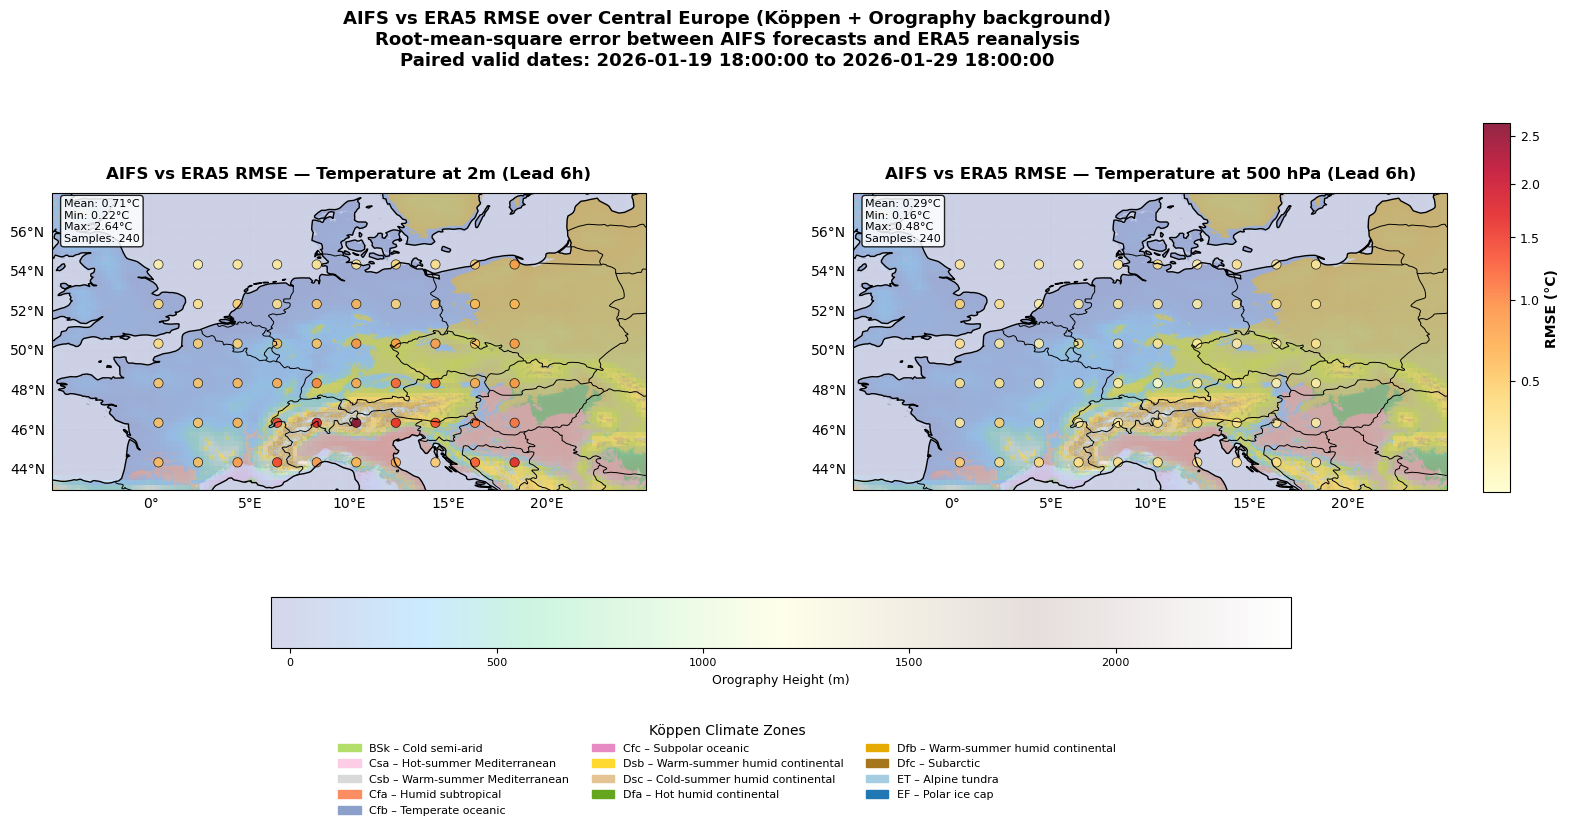


✓ Figure 1 complete in 2.16s
✓ Saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_maps_europe_koppen_orography.png


In [35]:
try:
    t_start = time.time()
    lon_min, lon_max, lat_min, lat_max = EUROPE_EXTENT
    
    # Load and crop Köppen
    koppen_image = None
    koppen_extent = None
    koppen_legend = None
    koppen_present_codes = []
    try:
        koppen_path = KOPPEN_RASTER
        if not koppen_path.exists():
            fallback = Path.home() / "Downloads" / "koppen_geiger_0p1.tif"
            if fallback.exists():
                koppen_path = fallback
        if koppen_path.exists():
            src = rasterio.open(str(koppen_path))
            koppen_full = src.read(1)
            koppen_transform = src.transform

            window = from_bounds(lon_min, lat_min, lon_max, lat_max, koppen_transform)
            row_min, col_min = int(window.row_off), int(window.col_off)
            row_max = row_min + int(window.height)
            col_max = col_min + int(window.width)
            koppen_crop = koppen_full[row_min:row_max, col_min:col_max]

            koppen_code_to_abbrev = {
                1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
                8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
                14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
                21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa", 26: "Dfb",
                27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF"
            }
            koppen_abbrev_to_full = {
                "Af": "Tropical rainforest",      "Am": "Tropical monsoon",
                "Aw": "Tropical savanna",         "BWh": "Hot desert",
                "BWk": "Cold desert",             "BSh": "Hot semi-arid",
                "BSk": "Cold semi-arid",          "Csa": "Hot-summer Mediterranean",
                "Csb": "Warm-summer Mediterranean", "Csc": "Cold-summer Mediterranean",
                "Cwa": "Subtropical monsoon",     "Cwb": "Subtropical highland",
                "Cwc": "Cold subtropical highland","Cfa": "Humid subtropical",
                "Cfb": "Temperate oceanic",       "Cfc": "Subpolar oceanic",
                "Dsa": "Hot-summer humid continental", "Dsb": "Warm-summer humid continental",
                "Dsc": "Cold-summer humid continental", "Dsd": "Extremely cold-summer continental",
                "Dwa": "Monsoon-influenced humid continental", "Dwb": "Dry-winter warm-summer continental",
                "Dwc": "Dry-winter cold-summer continental", "Dwd": "Dry-winter extremely cold-summer continental",
                "Dfa": "Hot humid continental",   "Dfb": "Warm-summer humid continental",
                "Dfc": "Subarctic",               "Dfd": "Extremely cold subarctic",
                "ET": "Alpine tundra",            "EF": "Polar ice cap"
            }

            palette = (
                list(plt.cm.Set3.colors)
                + list(plt.cm.Set2.colors)
                + list(plt.cm.Dark2.colors)
                + list(plt.cm.Paired.colors)
            )
            koppen_color_map = {code: palette[i % len(palette)] for i, code in enumerate(koppen_code_to_abbrev.keys())}

            colored_koppen = np.zeros((*koppen_crop.shape, 4), dtype=float)
            present_codes = sorted({int(c) for c in np.unique(koppen_crop) if int(c) in koppen_code_to_abbrev})
            koppen_present_codes = present_codes
            for code in present_codes:
                rgba = plt.matplotlib.colors.to_rgba(koppen_color_map.get(code, "#f0f0f0"))
                colored_koppen[koppen_crop == code] = rgba
            colored_koppen[(koppen_crop < 1) | (koppen_crop > 30)] = plt.matplotlib.colors.to_rgba("#f0f0f0")

            koppen_image = colored_koppen
            koppen_extent = [lon_min, lon_max, lat_min, lat_max]

            legend_patches = []
            for code in present_codes:
                abbrev = koppen_code_to_abbrev[code]
                full_name = koppen_abbrev_to_full.get(abbrev, "Unknown")
                patch = mpatches.Patch(color=koppen_color_map[code], label=f"{abbrev} – {full_name}")
                legend_patches.append(patch)
            koppen_legend = legend_patches

            print(f"✓ Köppen loaded: {koppen_crop.shape}, {len(present_codes)} classes")
            src.close()
    except Exception as e:
        print(f"⚠ Köppen background unavailable: {e}")
    
    # Load orography
    orog_image = None
    orog_vmin = None
    orog_vmax = None
    try:
        if OROG_RASTER.exists():
            ds_orog = xr.open_dataset(OROG_RASTER)
            if 'z' in ds_orog:
                z = ds_orog['z'] / 9.80665
                if z.ndim > 2:
                    z = z.squeeze()
                z_crop = z.sel(
                    longitude=slice(lon_min, lon_max),
                    latitude=slice(lat_max, lat_min)
                )
                z_values = np.squeeze(z_crop.values)
                if z_values.ndim == 2:
                    orog_image = z_values
                    orog_vmin, orog_vmax = np.nanmin(z_values), np.nanmax(z_values)
                    print(f"✓ Orography loaded: {z_values.shape}")
    except Exception as e:
        print(f"⚠ Orography unavailable: {e}")

    # Compute global RMSE scale
    global_vmin, global_vmax = None, None
    rmse_norm = None
    try:
        vals = []
        for var in VARIABLES:
            ds_step = load_rmse_by_step(var)
            rmse = ds_step['rmse'].isel(step=0).squeeze()
            lat_name = None
            lon_name = None
            for dim in rmse.dims:
                if dim in ('latitude', 'lat'):
                    lat_name = dim
                elif dim in ('longitude', 'lon'):
                    lon_name = dim
            if lat_name is None or lon_name is None:
                continue
            rmse_map = rmse.sel(
                **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
            ).sortby(lat_name)
            rmse_coarse = _maybe_coarsen(rmse_map, lat_name, lon_name, PLOT_CFG["rmse_coarsen_factor"])
            arr = rmse_coarse.values
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vals.append(arr)
        if vals:
            all_vals = np.concatenate(vals)
            if PLOT_CFG["rmse_vmin"] is not None and PLOT_CFG["rmse_vmax"] is not None:
                global_vmin = float(PLOT_CFG["rmse_vmin"])
                global_vmax = float(PLOT_CFG["rmse_vmax"])
            else:
                global_vmin = float(np.nanmin(all_vals))
                global_vmax = float(np.nanmax(all_vals))
            if PLOT_CFG["rmse_norm"] == "power":
                rmse_norm = mcolors.PowerNorm(
                    gamma=float(PLOT_CFG["rmse_gamma"]),
                    vmin=global_vmin,
                    vmax=global_vmax,
                )
            else:
                rmse_norm = mcolors.Normalize(vmin=global_vmin, vmax=global_vmax)
    except Exception:
        global_vmin, global_vmax = None, None
        rmse_norm = None

    print("SANITY FIG1 (RMSE maps):")
    for var in VARIABLES:
        dmin, dmax, n_ok = _pairs_date_range(pairs_dict.get(var))
        print(f"  {var}: ok_pairs={n_ok}, valid_dt range={dmin} to {dmax}")
    fig1_date_min, fig1_date_max, _ = _overall_ok_date_range(pairs_dict, VARIABLES)

    # Plot
    fig = plt.figure(figsize=(18, 8))
    gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.35)
    rmse_mappable = None
    orog_mappable = None
    
    for plot_idx, var in enumerate(VARIABLES):
        print(f"  Plotting {var}...")
        try:
            ax = fig.add_subplot(gs[0, plot_idx], projection=ccrs.PlateCarree())
            ax.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())
            
            ds_step = load_rmse_by_step(var)
            rmse = ds_step['rmse']
            rmse_full = rmse.isel(step=0).squeeze()
            step_val = int(rmse_full.step.values)
            
            lat_name = None
            lon_name = None
            for dim in rmse_full.dims:
                if dim in ('latitude', 'lat'):
                    lat_name = dim
                elif dim in ('longitude', 'lon'):
                    lon_name = dim
            
            if lat_name is None or lon_name is None:
                continue
            
            rmse_map = rmse_full.sel(
                **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
            )
            rmse_map = rmse_map.sortby(lat_name)
            rmse_coarse = _maybe_coarsen(rmse_map, lat_name, lon_name, PLOT_CFG["rmse_coarsen_factor"])
            
            lats = rmse_coarse[lat_name].values
            lons = rmse_coarse[lon_name].values
            rmse_plot = rmse_coarse.values
            
            # Köppen background
            if koppen_image is not None and koppen_extent is not None:
                ax.imshow(
                    koppen_image,
                    origin='upper',
                    extent=koppen_extent,
                    transform=ccrs.PlateCarree(),
                    alpha=PLOT_CFG["koppen_alpha"],
                    zorder=0
                )
            
            # Orography overlay
            if orog_image is not None:
                orog_mappable = ax.imshow(
                    orog_image,
                    origin='upper',
                    extent=[lon_min, lon_max, lat_min, lat_max],
                    cmap=PLOT_CFG["orog_cmap"],
                    transform=ccrs.PlateCarree(),
                    vmin=orog_vmin,
                    vmax=orog_vmax,
                    interpolation='nearest',
                    alpha=PLOT_CFG["orog_alpha"],
                    zorder=1
                )
            
            # RMSE dots
            valid_mask = ~np.isnan(rmse_plot)
            if global_vmin is not None and global_vmax is not None:
                vmin, vmax = global_vmin, global_vmax
            elif valid_mask.any():
                vmin = np.nanpercentile(rmse_plot, 5)
                vmax = np.nanpercentile(rmse_plot, 95)
            else:
                vmin, vmax = 0, 1
            
            stride = 2
            lon_grid, lat_grid = np.meshgrid(lons, lats)
            lon_scatter = lon_grid[::stride, ::stride].ravel()
            lat_scatter = lat_grid[::stride, ::stride].ravel()
            rmse_scatter = rmse_plot[::stride, ::stride].ravel()
            valid_idx = ~np.isnan(rmse_scatter)
            
            scatter_kwargs = dict(
                c=rmse_scatter[valid_idx],
                cmap=PLOT_CFG["rmse_cmap"],
                s=PLOT_CFG["rmse_size"],
                alpha=PLOT_CFG["rmse_alpha"],
                edgecolors=PLOT_CFG["rmse_edgecolor"],
                linewidths=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5,
                marker='o',
            )
            if rmse_norm is not None:
                scatter_kwargs["norm"] = rmse_norm
            else:
                scatter_kwargs["vmin"] = vmin
                scatter_kwargs["vmax"] = vmax

            scatter = ax.scatter(
                lon_scatter[valid_idx],
                lat_scatter[valid_idx],
                **scatter_kwargs
            )
            if rmse_mappable is None:
                rmse_mappable = scatter
            
            # Map features
            ax.coastlines(linewidth=1.0, color='black', zorder=10)
            ax.add_feature(cfeature.BORDERS, linewidth=0.7, color='black', linestyle='-', zorder=10)
            gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.2, alpha=0.4, zorder=2)
            gl.top_labels = False
            gl.right_labels = False
            
            # Title and stats
            ax.set_title(
                f"AIFS vs ERA5 RMSE — {VAR_LABELS.get(var, var)} (Lead {step_val}h)",
                fontsize=12, fontweight='bold', pad=10
            )
            
            if valid_mask.any():
                mean_val = np.nanmean(rmse_plot[valid_mask])
                min_val = np.nanmin(rmse_plot[valid_mask])
                max_val = np.nanmax(rmse_plot[valid_mask])
                stats_text = (
                    f'Mean: {mean_val:.2f}°C\n'
                    f'Min: {min_val:.2f}°C\n'
                    f'Max: {max_val:.2f}°C\n'
                    f'Samples: {valid_mask.sum()}'
                )
                ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                       fontsize=8, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.85), zorder=20)
            
        except Exception as e:
            ax = fig.add_subplot(gs[0, plot_idx])
            error_msg = f'{type(e).__name__}: {str(e)[:60]}'
            ax.text(0.5, 0.5, f'Error:\n{error_msg}',
                   ha='center', va='center', fontsize=9, color='red')
            ax.axis('off')

    # Colorbars
    if rmse_mappable is not None:
        cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
        cbar_rmse = fig.colorbar(rmse_mappable, cax=cax, orientation='vertical')
        cbar_rmse.set_label('RMSE (°C)', fontsize=10, fontweight='bold')
        cbar_rmse.ax.tick_params(labelsize=9)

    if orog_mappable is not None:
        cbar_orog = fig.colorbar(orog_mappable, ax=fig.axes, orientation='horizontal', shrink=0.7, pad=0.08)
        cbar_orog.set_label('Orography Height (m)', fontsize=9)
        cbar_orog.ax.tick_params(labelsize=8)

    # Legend
    if koppen_legend:
        fig.legend(
            handles=koppen_legend,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.06),
            ncol=PLOT_CFG["legend_cols"],
            fontsize=8,
            title="Köppen Climate Zones",
            frameon=False
        )

    # Title
    suptitle = (
        "AIFS vs ERA5 RMSE over Central Europe (Köppen + Orography background)\n"
        "Root-mean-square error between AIFS forecasts and ERA5 reanalysis\n"
        f"Paired valid dates: {fig1_date_min} to {fig1_date_max}"
    )
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=0.96)
    fig.subplots_adjust(bottom=0.36, right=0.90, top=0.86)
    
    fig_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_maps_europe_koppen_orography.png')
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Figure 1 complete in {time.time()-t_start:.2f}s")
    print(f"✓ Saved to: {fig_path}")
    plt.close(fig)

except Exception as e:
    print(f"\n✗ Figure 1 failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

## 7. Figure 2: Mean RMSE vs Lead Time

Time series of mean RMSE aggregated by forecast lead time (skill proxy).

SANITY FIG2 (Mean RMSE vs Lead Time):
  2t: ok_pairs=105, valid_dt range=2026-01-19 18:00:00 to 2026-01-29 18:00:00
  t500: ok_pairs=105, valid_dt range=2026-01-19 18:00:00 to 2026-01-29 18:00:00
  steps used: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(36), np.int64(48)]
✓ Figure 2 saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_mean_by_lead_time.png


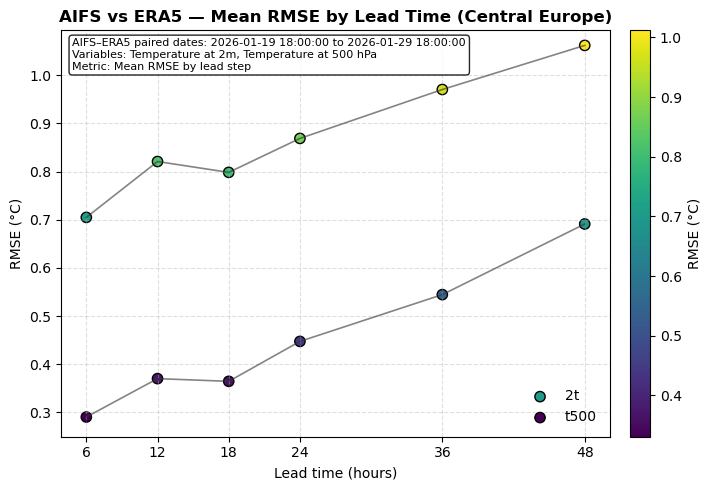

In [36]:
try:
    fig2 = plt.figure(figsize=(7.5, 5.0))
    ax2 = fig2.add_subplot(1, 1, 1)
    all_rows = []
    for var in VARIABLES:
        csv_path = RMSE_OUT / f'rmse_by_step_{var}.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df["variable"] = var
        all_rows.append(df)
    if all_rows:
        df_all = pd.concat(all_rows, ignore_index=True)
    else:
        df_all = pd.DataFrame(columns=["step", "rmse_mean", "variable"])

    print("SANITY FIG2 (Mean RMSE vs Lead Time):")
    for var in VARIABLES:
        dmin, dmax, n_ok = _pairs_date_range(pairs_dict.get(var))
        print(f"  {var}: ok_pairs={n_ok}, valid_dt range={dmin} to {dmax}")
    if not df_all.empty:
        steps = sorted(df_all["step"].unique())
        print(f"  steps used: {steps}")
    else:
        print("  steps used: N/A (no data)")

    # Determine y-range
    if not df_all.empty:
        if PLOT_CFG["skill_vmin"] is not None and PLOT_CFG["skill_vmax"] is not None:
            y_min = float(PLOT_CFG["skill_vmin"])
            y_max = float(PLOT_CFG["skill_vmax"])
        else:
            p_lo, p_hi = PLOT_CFG["skill_pct"]
            y_min = float(np.nanpercentile(df_all["rmse_mean"], p_lo))
            y_max = float(np.nanpercentile(df_all["rmse_mean"], p_hi))
    else:
        y_min, y_max = None, None

    # Plot
    cmap = plt.get_cmap(PLOT_CFG["skill_cmap"])
    norm = None
    if y_min is not None and y_max is not None:
        norm = mcolors.Normalize(vmin=y_min, vmax=y_max)

    for var in VARIABLES:
        df = df_all[df_all["variable"] == var]
        if df.empty:
            continue
        if norm is not None:
            colors = cmap(norm(df["rmse_mean"].values))
        else:
            colors = None
        ax2.plot(df['step'], df['rmse_mean'], color="#333333", linewidth=1.2, alpha=0.6)
        ax2.scatter(df['step'], df['rmse_mean'], c=colors, cmap=cmap, norm=norm, s=55, label=var, edgecolors="black")
    
    ax2.set_title("AIFS vs ERA5 — Mean RMSE by Lead Time (Central Europe)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Lead time (hours)")
    ax2.set_ylabel("RMSE (°C)")
    if y_min is not None and y_max is not None:
        pad = 0.12 * (y_max - y_min) if y_max > y_min else 0.15
        ax2.set_ylim(y_min - pad, y_max + pad)
    ax2.margins(y=0.08)
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.legend(frameon=False)
    
    if not df_all.empty:
        steps = sorted(df_all["step"].unique())
        ax2.set_xticks(steps)
    
    if norm is not None:
        cbar2 = fig2.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            ax=ax2, orientation='vertical', pad=0.03
        )
        cbar2.set_label("RMSE (°C)")

    date_min, date_max, _ = _overall_ok_date_range(pairs_dict, VARIABLES)
    ax2.text(
        0.02, 0.98,
        f"AIFS–ERA5 paired dates: {date_min} to {date_max}\n"
        f"Variables: {', '.join([VAR_LABELS.get(v, v) for v in VARIABLES if v in df_all['variable'].unique()])}\n"
        "Metric: Mean RMSE by lead step",
        transform=ax2.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    fig2.tight_layout()
    fig2_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_mean_by_lead_time.png')
    fig2.savefig(fig2_path, dpi=140, bbox_inches='tight')
    print(f"✓ Figure 2 saved to: {fig2_path}")
    plt.show()
except Exception as e:
    print(f"✗ Figure 2 failed: {type(e).__name__}: {e}")

## 8. Figure 3: 2m Temperature RMSE at Different UTC Hours (Köppen Background)

Diurnal comparison at 06:00 and 18:00 UTC with Köppen climate zones overlay.

✓ Figure 3 saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_2mtemp_koppen_06_18utc.png


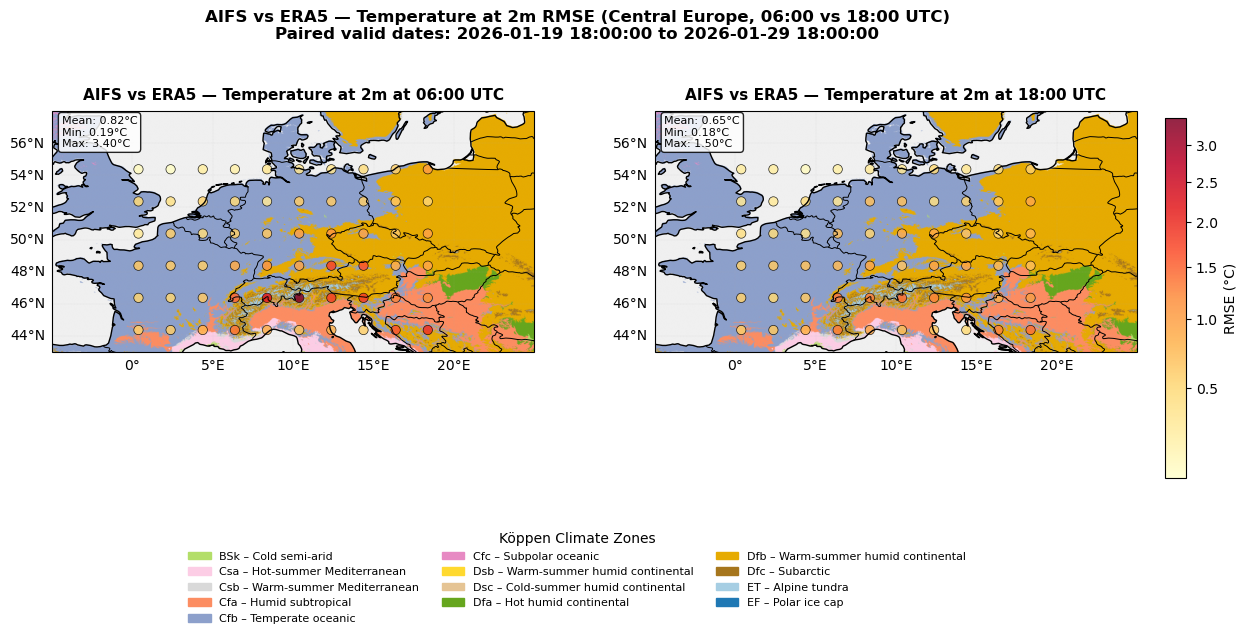

In [37]:
try:
    fig3 = plt.figure(figsize=(14, 6))
    gs3 = gridspec.GridSpec(1, 2, figure=fig3, hspace=0.3, wspace=0.25)
    hours = [6, 18]
    rmse_cache = {}

    ds_hour = load_rmse_by_hour("2t")
    for hour_val in hours:
        rmse = ds_hour['rmse'].sel(hour=hour_val).squeeze()
        lat_name = 'latitude' if 'latitude' in rmse.dims else 'lat'
        lon_name = 'longitude' if 'longitude' in rmse.dims else 'lon'
        rmse_map = rmse.sel(
            **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
        ).sortby(lat_name)
        rmse_coarse = _maybe_coarsen(rmse_map, lat_name, lon_name, PLOT_CFG["rmse_coarsen_factor"])
        rmse_cache[hour_val] = {
            "lat_name": lat_name,
            "lon_name": lon_name,
            "lats": rmse_coarse[lat_name].values,
            "lons": rmse_coarse[lon_name].values,
            "rmse_plot": rmse_coarse.values,
        }

    all_vals = np.concatenate([v["rmse_plot"][np.isfinite(v["rmse_plot"])] for v in rmse_cache.values()])
    if all_vals.size > 0:
        vmin3 = float(np.nanmin(all_vals))
        vmax3 = float(np.nanmax(all_vals))
        norm3 = mcolors.PowerNorm(gamma=float(PLOT_CFG["rmse_gamma"]), vmin=vmin3, vmax=vmax3)
    else:
        vmin3, vmax3, norm3 = None, None, None

    for i, hour_val in enumerate(hours):
        axh = fig3.add_subplot(gs3[0, i], projection=ccrs.PlateCarree())
        axh.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())

        if koppen_image is not None and koppen_extent is not None:
            axh.imshow(
                koppen_image,
                origin='upper',
                extent=koppen_extent,
                transform=ccrs.PlateCarree(),
                alpha=1.0,
                zorder=0
            )

        cached = rmse_cache[hour_val]
        lats = cached["lats"]
        lons = cached["lons"]
        rmse_plot = cached["rmse_plot"]

        lon_grid, lat_grid = np.meshgrid(lons, lats)
        stride = 2
        lon_scatter = lon_grid[::stride, ::stride].ravel()
        lat_scatter = lat_grid[::stride, ::stride].ravel()
        rmse_scatter = rmse_plot[::stride, ::stride].ravel()
        valid_idx = ~np.isnan(rmse_scatter)

        scatter_kwargs = dict(
            c=rmse_scatter[valid_idx],
            cmap=PLOT_CFG["rmse_cmap"],
            s=PLOT_CFG["rmse_size"],
            alpha=PLOT_CFG["rmse_alpha"],
            edgecolors=PLOT_CFG["rmse_edgecolor"],
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=5,
            marker='o',
        )
        if norm3 is not None:
            scatter_kwargs["norm"] = norm3
        else:
            scatter_kwargs["vmin"] = vmin3
            scatter_kwargs["vmax"] = vmax3

        sc = axh.scatter(lon_scatter[valid_idx], lat_scatter[valid_idx], **scatter_kwargs)

        axh.coastlines(linewidth=1.0, color='black', zorder=10)
        axh.add_feature(cfeature.BORDERS, linewidth=0.7, color='black', linestyle='-', zorder=10)
        gl = axh.gridlines(draw_labels=True, linestyle='--', linewidth=0.2, alpha=0.4, zorder=2)
        gl.top_labels = False
        gl.right_labels = False

        axh.set_title(
            f"AIFS vs ERA5 — {VAR_LABELS.get('2t', '2t')} at {hour_val:02d}:00 UTC",
            fontsize=11, fontweight='bold', pad=8
        )

        if valid_idx.any():
            mean_val = float(np.nanmean(rmse_plot))
            min_val = float(np.nanmin(rmse_plot))
            max_val = float(np.nanmax(rmse_plot))
            stats_text = f"Mean: {mean_val:.2f}°C\nMin: {min_val:.2f}°C\nMax: {max_val:.2f}°C"
            axh.text(
                0.02, 0.98, stats_text,
                transform=axh.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85), zorder=20
            )

    cax3 = fig3.add_axes([0.92, 0.20, 0.015, 0.60])
    fig3.colorbar(sc, cax=cax3, orientation='vertical').set_label("RMSE (°C)")

    date_min, date_max, _ = _overall_ok_date_range(pairs_dict, VARIABLES)
    fig3.suptitle(
        f"AIFS vs ERA5 — {VAR_LABELS.get('2t', '2t')} RMSE (Central Europe, 06:00 vs 18:00 UTC)\n"
        f"Paired valid dates: {date_min} to {date_max}",
        fontsize=12, fontweight='bold', y=0.98
    )
    fig3.subplots_adjust(right=0.90, bottom=0.36, top=0.86)

    if koppen_legend:
        fig3.legend(
            handles=koppen_legend,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.06),
            ncol=PLOT_CFG["legend_cols"],
            fontsize=8,
            title="Köppen Climate Zones",
            frameon=False
        )

    fig3_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_2mtemp_koppen_06_18utc.png')
    fig3.savefig(fig3_path, dpi=140, bbox_inches='tight')
    print(f"✓ Figure 3 saved to: {fig3_path}")
    plt.show()
except Exception as e:
    print(f"✗ Figure 3 failed: {type(e).__name__}: {e}")

## 9. Figure 4: 2m Temperature RMSE at Different UTC Hours (Orography Background)

Diurnal comparison at 00:00 and 12:00 UTC with custom terrain elevation colormap.

✓ Figure 4 saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_2mtemp_orography_00_12utc.png


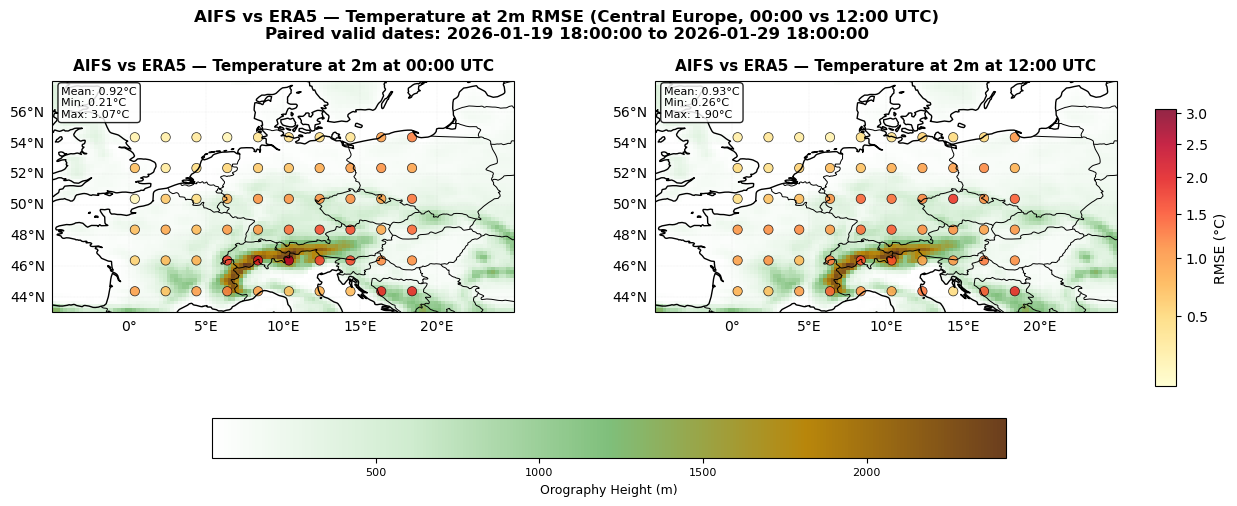

In [38]:
try:
    fig4 = plt.figure(figsize=(14, 6))
    gs4 = gridspec.GridSpec(1, 2, figure=fig4, hspace=0.3, wspace=0.25)
    hours4 = [0, 12]
    rmse_cache4 = {}

    ds_hour4 = load_rmse_by_hour("2t")
    for hour_val in hours4:
        rmse = ds_hour4['rmse'].sel(hour=hour_val).squeeze()
        lat_name = 'latitude' if 'latitude' in rmse.dims else 'lat'
        lon_name = 'longitude' if 'longitude' in rmse.dims else 'lon'
        rmse_map = rmse.sel(
            **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
        ).sortby(lat_name)
        rmse_coarse = _maybe_coarsen(rmse_map, lat_name, lon_name, PLOT_CFG["rmse_coarsen_factor"])
        rmse_cache4[hour_val] = {
            "lat_name": lat_name,
            "lon_name": lon_name,
            "lats": rmse_coarse[lat_name].values,
            "lons": rmse_coarse[lon_name].values,
            "rmse_plot": rmse_coarse.values,
        }

    all_vals4 = np.concatenate([v["rmse_plot"][np.isfinite(v["rmse_plot"])] for v in rmse_cache4.values()])
    if all_vals4.size > 0:
        vmin4 = float(np.nanmin(all_vals4))
        vmax4 = float(np.nanmax(all_vals4))
        norm4 = mcolors.PowerNorm(gamma=float(PLOT_CFG["rmse_gamma"]), vmin=vmin4, vmax=vmax4)
    else:
        vmin4, vmax4, norm4 = None, None, None

    orog_cmap4 = mcolors.LinearSegmentedColormap.from_list(
        "orog_white_green_brown",
        ["#ffffff", "#cfeccf", "#7fbf7b", "#b8860b", "#6b3e1e"]
    )
    orog_cmap4.set_under("#ffffff")

    for i, hour_val in enumerate(hours4):
        axh = fig4.add_subplot(gs4[0, i], projection=ccrs.PlateCarree())
        axh.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())

        if orog_image is not None:
            axh.imshow(
                orog_image,
                origin='upper',
                extent=[lon_min, lon_max, lat_min, lat_max],
                cmap=orog_cmap4,
                transform=ccrs.PlateCarree(),
                vmin=0.1,
                vmax=orog_vmax,
                interpolation='nearest',
                alpha=1.0,
                zorder=0
            )

        cached = rmse_cache4[hour_val]
        lats = cached["lats"]
        lons = cached["lons"]
        rmse_plot = cached["rmse_plot"]

        lon_grid, lat_grid = np.meshgrid(lons, lats)
        stride = 2
        lon_scatter = lon_grid[::stride, ::stride].ravel()
        lat_scatter = lat_grid[::stride, ::stride].ravel()
        rmse_scatter = rmse_plot[::stride, ::stride].ravel()
        valid_idx = ~np.isnan(rmse_scatter)

        scatter_kwargs = dict(
            c=rmse_scatter[valid_idx],
            cmap=PLOT_CFG["rmse_cmap"],
            s=PLOT_CFG["rmse_size"],
            alpha=PLOT_CFG["rmse_alpha"],
            edgecolors=PLOT_CFG["rmse_edgecolor"],
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=5,
            marker='o',
        )
        if norm4 is not None:
            scatter_kwargs["norm"] = norm4
        else:
            scatter_kwargs["vmin"] = vmin4
            scatter_kwargs["vmax"] = vmax4

        sc4 = axh.scatter(lon_scatter[valid_idx], lat_scatter[valid_idx], **scatter_kwargs)

        axh.coastlines(linewidth=1.0, color='black', zorder=10)
        axh.add_feature(cfeature.BORDERS, linewidth=0.7, color='black', linestyle='-', zorder=10)
        gl = axh.gridlines(draw_labels=True, linestyle='--', linewidth=0.2, alpha=0.4, zorder=2)
        gl.top_labels = False
        gl.right_labels = False

        axh.set_title(
            f"AIFS vs ERA5 — {VAR_LABELS.get('2t', '2t')} at {hour_val:02d}:00 UTC",
            fontsize=11, fontweight='bold', pad=8
        )

        if valid_idx.any():
            mean_val = float(np.nanmean(rmse_plot))
            min_val = float(np.nanmin(rmse_plot))
            max_val = float(np.nanmax(rmse_plot))
            stats_text = f"Mean: {mean_val:.2f}°C\nMin: {min_val:.2f}°C\nMax: {max_val:.2f}°C"
            axh.text(
                0.02, 0.98, stats_text,
                transform=axh.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85), zorder=20
            )

    cax4 = fig4.add_axes([0.92, 0.20, 0.015, 0.60])
    fig4.colorbar(sc4, cax=cax4, orientation='vertical').set_label("RMSE (°C)")

    date_min, date_max, _ = _overall_ok_date_range(pairs_dict, VARIABLES)
    fig4.suptitle(
        f"AIFS vs ERA5 — {VAR_LABELS.get('2t', '2t')} RMSE (Central Europe, 00:00 vs 12:00 UTC)\n"
        f"Paired valid dates: {date_min} to {date_max}",
        fontsize=12, fontweight='bold', y=0.98
    )
    fig4.subplots_adjust(right=0.90, bottom=0.36, top=0.86)

    if orog_image is not None:
        try:
            cbar_orog4 = fig4.colorbar(
                plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.1, vmax=orog_vmax), cmap=orog_cmap4),
                ax=fig4.axes,
                orientation='horizontal',
                shrink=0.7,
                pad=0.08
            )
            cbar_orog4.set_label('Orography Height (m)', fontsize=9)
            cbar_orog4.ax.tick_params(labelsize=8)
        except Exception:
            pass

    fig4_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_2mtemp_orography_00_12utc.png')
    fig4.savefig(fig4_path, dpi=140, bbox_inches='tight')
    print(f"✓ Figure 4 saved to: {fig4_path}")
    plt.show()
except Exception as e:
    print(f"✗ Figure 4 failed: {type(e).__name__}: {e}")

## 10. Figure 5: RMSE Distribution by Lead Time

Boxplots showing RMSE variability across forecast lead times for each variable.

✓ Figure 5 saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_distribution_by_lead_time.png


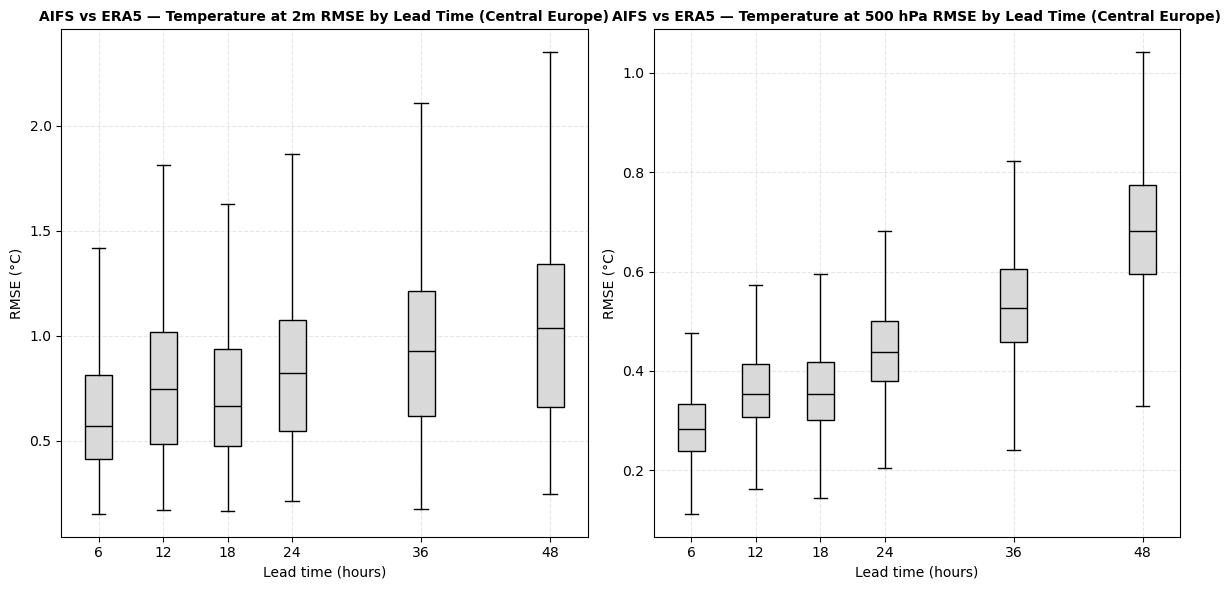

In [42]:
try:
    fig5 = plt.figure(figsize=(12, 6))
    ax5a = fig5.add_subplot(1, 2, 1)
    ax5b = fig5.add_subplot(1, 2, 2)

    def _rmse_by_step_distribution_from_cache(var_key):
        """Load pre-computed RMSE by step from NetCDF (fast, ~100x speedup vs on-demand)."""
        nc_path = RMSE_OUT / f'rmse_by_step_{var_key}.nc'
        if not nc_path.exists():
            return {}
        
        ds = xr.open_dataset(nc_path)
        rmse_grid = ds['rmse']  # Shape: (step, latitude, longitude)
        
        # Extract RMSE values for each step, flattened to distribution list
        step_map = {}
        for step in rmse_grid.coords['step'].values:
            rmse_at_step = rmse_grid.sel(step=int(step)).values
            # Flatten and remove NaNs to get distribution of RMSE values across grid cells
            valid_rmse = rmse_at_step[~np.isnan(rmse_at_step)]
            if valid_rmse.size > 0:
                step_map[int(step)] = valid_rmse.tolist()
        
        ds.close()
        return step_map

    for ax, var_key in [(ax5a, "2t"), (ax5b, "t500")]:
        step_map = _rmse_by_step_distribution_from_cache(var_key)
        if not step_map:
            ax.text(0.5, 0.5, f'No data for {var_key}', ha='center', va='center')
            ax.axis('off')
            continue
        steps = sorted(step_map.keys())
        data = [step_map[s] for s in steps]
        ax.boxplot(
            data,
            positions=steps,
            widths=2.5,
            patch_artist=True,
            boxprops=dict(facecolor="#d9d9d9", edgecolor="black"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            showfliers=False,
        )
        ax.set_title(
            f"AIFS vs ERA5 — {VAR_LABELS.get(var_key, var_key)} RMSE by Lead Time (Central Europe)",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel("Lead time (hours)")
        ax.set_ylabel("RMSE (°C)")
        ax.set_xticks(steps)
        ax.grid(True, linestyle='--', alpha=0.3)

    fig5.tight_layout()
    fig5_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_distribution_by_lead_time.png')
    fig5.savefig(fig5_path, dpi=140, bbox_inches='tight')
    print(f"✓ Figure 5 saved to: {fig5_path}")
    plt.show()
except Exception as e:
    print(f"✗ Figure 5 failed: {type(e).__name__}: {e}")

## 11. Figure 6: RMSE vs Land-Sea Mask

Comparison of RMSE over land vs ocean with spatial map and distribution boxplot.

✓ Figure 6 saved to: /Users/yeganehkhabbazian/Projects/Earth_System/earth-system-data-processing/results/aifs_vs_era5_rmse_land_vs_sea.png


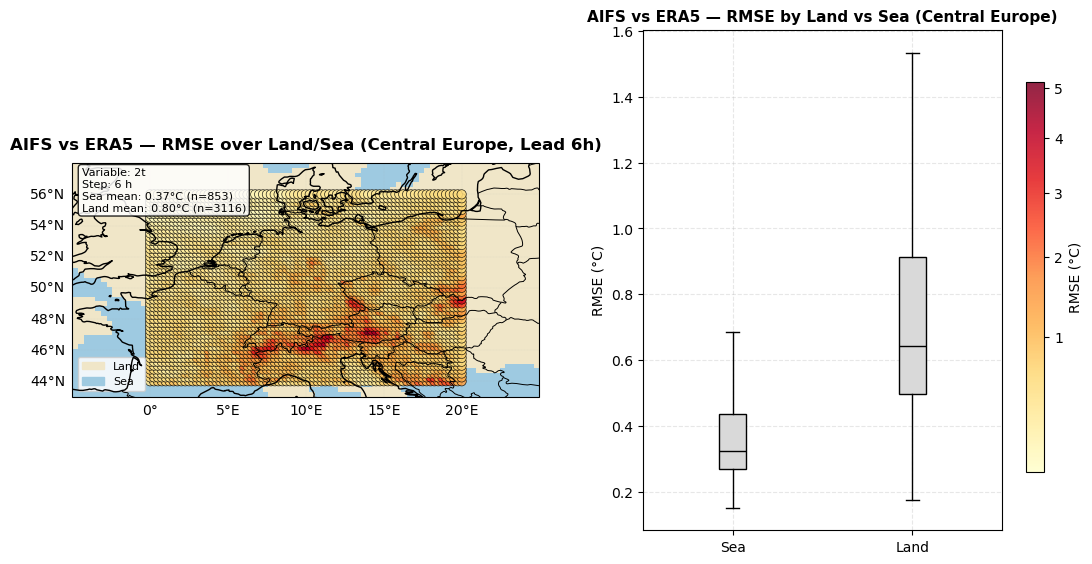

In [40]:
try:
    if lsm_da is None:
        raise ValueError("Land-sea mask not available. Download era5_land_sea_mask.nc first.")

    var_key = PLOT_CFG["lsm_var"]
    step_target = float(PLOT_CFG["lsm_step_hours"])

    ds_step = load_rmse_by_step(var_key)
    rmse = ds_step["rmse"]

    lat_name = None
    lon_name = None
    for dim in rmse.dims:
        if dim in ("latitude", "lat"):
            lat_name = dim
        elif dim in ("longitude", "lon"):
            lon_name = dim
    if lat_name is None or lon_name is None:
        raise ValueError("RMSE dataset missing latitude/longitude dimensions")

    if "step" not in rmse.dims:
        raise ValueError("RMSE dataset missing step dimension")

    step_vals = rmse["step"].values.astype(float)
    if step_vals.size == 0:
        raise ValueError("RMSE dataset has no steps")
    step_idx = int(np.nanargmin(np.abs(step_vals - step_target)))
    step_used = float(step_vals[step_idx])

    rmse_step = rmse.isel(step=step_idx).sel(
        **{lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min, lon_max)}
    ).sortby(lat_name)

    rmse_vals = np.asarray(rmse_step.values)
    if np.all(np.isnan(rmse_vals)):
        raise ValueError("RMSE step map is all NaN")

    # Regrid LSM onto RMSE grid
    lsm_on_rmse = lsm_da.interp(
        **{
            lsm_lat_name: rmse_step[lat_name].values,
            lsm_lon_name: rmse_step[lon_name].values,
        },
        method="nearest",
    )
    lsm_vals = np.asarray(lsm_on_rmse.values)

    land_mask = lsm_vals >= 0.5
    sea_mask = lsm_vals < 0.5
    valid_mask = ~np.isnan(rmse_vals)

    land_rmse = rmse_vals[land_mask & valid_mask]
    sea_rmse = rmse_vals[sea_mask & valid_mask]

    fig6 = plt.figure(figsize=(12, 6.5))
    gs6 = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1.0], wspace=0.25)
    ax6_map = fig6.add_subplot(gs6[0, 0], projection=ccrs.PlateCarree())
    ax6_dist = fig6.add_subplot(gs6[0, 1])

    ax6_map.set_extent(EUROPE_EXTENT, crs=ccrs.PlateCarree())

    lsm_cmap = ListedColormap([PLOT_CFG["lsm_sea_color"], PLOT_CFG["lsm_land_color"]])
    ax6_map.imshow(
        lsm_vals,
        origin="upper",
        extent=[lon_min, lon_max, lat_min, lat_max],
        cmap=lsm_cmap,
        vmin=0.0,
        vmax=1.0,
        transform=ccrs.PlateCarree(),
        interpolation="nearest",
        alpha=1.0,
        zorder=0,
    )

    rmse_vals = np.asarray(rmse_step.values)
    lon_grid, lat_grid = np.meshgrid(
        rmse_step[lon_name].values,
        rmse_step[lat_name].values
    )
    rmse_scatter = rmse_vals.ravel()
    lon_scatter = lon_grid.ravel()
    lat_scatter = lat_grid.ravel()
    ok = ~np.isnan(rmse_scatter)

    vmin6 = float(np.nanmin(rmse_vals)) if PLOT_CFG["rmse_vmin"] is None else float(PLOT_CFG["rmse_vmin"])
    vmax6 = float(np.nanmax(rmse_vals)) if PLOT_CFG["rmse_vmax"] is None else float(PLOT_CFG["rmse_vmax"])
    if PLOT_CFG["rmse_norm"] == "power":
        norm6 = mcolors.PowerNorm(gamma=float(PLOT_CFG["rmse_gamma"]), vmin=vmin6, vmax=vmax6)
    else:
        norm6 = mcolors.Normalize(vmin=vmin6, vmax=vmax6)

    sc6 = ax6_map.scatter(
        lon_scatter[ok],
        lat_scatter[ok],
        c=rmse_scatter[ok],
        cmap=PLOT_CFG["rmse_cmap"],
        s=PLOT_CFG["rmse_size"],
        alpha=PLOT_CFG["rmse_alpha"],
        edgecolors=PLOT_CFG["rmse_edgecolor"],
        linewidths=0.5,
        transform=ccrs.PlateCarree(),
        zorder=5,
        norm=norm6,
    )

    ax6_map.coastlines(linewidth=1.0, color="black", zorder=10)
    ax6_map.add_feature(cfeature.BORDERS, linewidth=0.7, color="black", linestyle="-", zorder=10)
    gl = ax6_map.gridlines(draw_labels=True, linestyle="--", linewidth=0.2, alpha=0.4, zorder=2)
    gl.top_labels = False
    gl.right_labels = False

    land_patch = mpatches.Patch(color=PLOT_CFG["lsm_land_color"], label="Land")
    sea_patch = mpatches.Patch(color=PLOT_CFG["lsm_sea_color"], label="Sea")
    ax6_map.legend(
        handles=[land_patch, sea_patch],
        loc="lower left",
        frameon=True,
        framealpha=0.85,
        fontsize=8
    )

    data = [sea_rmse, land_rmse]
    labels = ["Sea", "Land"]
    ax6_dist.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="#d9d9d9", edgecolor="black"),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        showfliers=False,
    )
    ax6_dist.set_title("AIFS vs ERA5 — RMSE by Land vs Sea (Central Europe)", fontsize=11, fontweight="bold")
    ax6_dist.set_ylabel("RMSE (°C)")
    ax6_dist.grid(True, linestyle="--", alpha=0.3)

    info = (
        f"Variable: {var_key}\n"
        f"Step: {step_used:.0f} h\n"
        f"Sea mean: {np.nanmean(sea_rmse):.2f}°C (n={sea_rmse.size})\n"
        f"Land mean: {np.nanmean(land_rmse):.2f}°C (n={land_rmse.size})"
    )
    ax6_map.text(
        0.02, 0.98, info,
        transform=ax6_map.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85), zorder=20
    )

    ax6_map.set_title(
        f"AIFS vs ERA5 — RMSE over Land/Sea (Central Europe, Lead {step_used:.0f}h)",
        fontsize=12, fontweight="bold", pad=10
    )

    cax6 = fig6.add_axes([0.92, 0.20, 0.015, 0.60])
    fig6.colorbar(sc6, cax=cax6, orientation="vertical").set_label("RMSE (°C)")

    fig6_path = str(RESULTS_DIR / 'aifs_vs_era5_rmse_land_vs_sea.png')
    fig6.savefig(fig6_path, dpi=140, bbox_inches="tight")
    print(f"✓ Figure 6 saved to: {fig6_path}")
    plt.show()
except Exception as e:
    print(f"✗ Figure 6 failed: {type(e).__name__}: {e}")